# Blog Writing Agent v3 — Router + Research (Tavily) + Orchestrator-Worker

```
__start__ -> router -> [research?] -> orchestrator -> worker(s) -> reducer -> __end__
```

- **router** — decides `closed_book` / `hybrid` / `open_book` and, if research is
  needed, generates search queries.
- **research** — runs the queries through Tavily and normalizes/dedups the
  results into an `EvidenceItem` list directly in code (no LLM call — see note
  below).
- **orchestrator** — plans the blog (`Plan` of `Task`s), grounded in evidence
  when available.
- **worker** — one per task via `Send()`, writes the section, citing evidence
  URLs when required.
- **reducer** — stitches sections (in task-id order) into one markdown file.

Uses Groq instead of OpenAI: `llm` (`llama-3.1-8b-instant`) for free-form
generation, `structured_llm` (`openai/gpt-oss-20b`) for structured output
calls (`RouterDecision`, `Plan`) since `llama-3.1-8b-instant` doesn't support
`method="json_schema"` on Groq.

Fixes vs. the pasted version:

1. `Task.bullets` has no `min_length`/`max_length` — Groq's `json_schema` mode
   (like OpenAI strict mode) doesn't support JSON Schema's `minItems`/
   `maxItems`; leaving them in causes `json_validate_failed` with an empty
   `failed_generation`. The "3-6 bullets" rule is enforced via the prompt.
2. `research_node` no longer sends raw search results through an LLM
   (`EvidencePack` extractor). Dumping every query's raw results into one
   prompt hit Groq's free-tier TPM limit (`413 rate_limit_exceeded`: 8000 TPM
   for `openai/gpt-oss-20b`). Tavily already returns structured
   title/url/snippet/date fields, so normalizing + deduping by URL in plain
   Python needs no LLM call at all and can't hit a token limit.
3. Every LLM-calling node (`router`, `orchestrator`, `worker`) gets a
   `RetryPolicy` with backoff. `worker` fans out concurrently via `Send()`, so
   several workers' combined token usage in one short window can exceed
   Groq's free-tier TPM (`429 rate_limit_exceeded`: 6000 TPM for
   `llama-3.1-8b-instant`) even though each individual call is small. Retrying
   with backoff — instead of crashing the whole run — is the standard way to
   handle a transient rate limit.


In [38]:
from __future__ import annotations

import operator
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, RetryPolicy

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

True

In [39]:
# -----------------------------
# 1) Schemas
# -----------------------------
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        description="3-6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ..., description="Target word count for this section (120-550)."
    )

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal[
        "explainer", "tutorial", "news_roundup", "comparison", "system_design"
    ] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)

In [40]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    final: str

In [41]:
# -----------------------------
# 2) LLM
# -----------------------------
llm = ChatGroq(model="llama-3.1-8b-instant")

# llama-3.1-8b-instant doesn't support method="json_schema" on Groq, so a
# separate model handles every structured-output call below.
structured_llm = ChatGroq(model="openai/gpt-oss-20b")

# groq.RateLimitError isn't in LangGraph's default_retry_on exclusion list, so
# it's already retried by default — this just tunes the backoff to match
# Groq's free-tier "please try again in Ns" TPM windows.
llm_retry_policy = RetryPolicy(
    max_attempts=5, initial_interval=10, backoff_factor=2.0, max_interval=60
)

In [42]:
# -----------------------------
# 3) Router (decide upfront)
# -----------------------------
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3-6 high-signal queries (do not exceed 6).
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""


def router_node(state: State) -> dict:
    topic = state["topic"]
    decider = structured_llm.with_structured_output(
        RouterDecision, method="json_schema"
    )
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries[:5],
    }


def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"

In [43]:
# -----------------------------
# 4) Research (Tavily) — normalized/deduped in plain Python, no LLM call.
#
# Tavily already returns structured title/url/content/date fields, so there is
# nothing for an LLM to "extract" here — and routing the raw results through
# one is what triggered the 413 rate_limit_exceeded (TPM) error, since a
# handful of queries x several results each easily exceeds Groq's free-tier
# 8000 TPM limit for openai/gpt-oss-20b in a single prompt.
# -----------------------------
def _tavily_search(query: str, max_results: int = 4) -> List[dict]:
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        snippet = r.get("content") or r.get("snippet") or ""
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": snippet[:300],  # keep evidence passed downstream small
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


def research_node(state: State) -> dict:
    queries = (state.get("queries", []) or [])[:5]

    raw_results: List[dict] = []
    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=4))

    # dedupe by URL, cap total evidence passed to the orchestrator/worker
    dedup: dict[str, EvidenceItem] = {}
    for r in raw_results:
        if r["url"] and r["url"] not in dedup:
            dedup[r["url"]] = EvidenceItem(**r)

    return {"evidence": list(dedup.values())[:16]}

In [44]:
# -----------------------------
# 5) Orchestrator (Plan)
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5-9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3-6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120-550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""


def orchestrator_node(state: State) -> dict:
    planner = structured_llm.with_structured_output(Plan, method="json_schema")

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )

    return {"plan": plan}

In [45]:
# -----------------------------
# 6) Fanout
# -----------------------------
def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]

In [46]:
# -----------------------------
# 7) Worker (write one section)
# -----------------------------
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""


def worker_node(payload: dict) -> dict:
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [47]:
# -----------------------------
# 8) Reducer (merge + save)
# -----------------------------
def reducer_node(state: State) -> dict:
    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    filename = f"{plan.blog_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

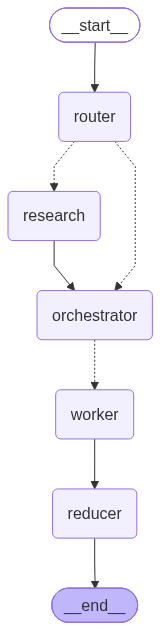

In [48]:
# -----------------------------
# 9) Build graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node, retry_policy=llm_retry_policy)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node, retry_policy=llm_retry_policy)
g.add_node("worker", worker_node, retry_policy=llm_retry_policy)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges(
    "router", route_next, {"research": "research", "orchestrator": "orchestrator"}
)
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [49]:
# -----------------------------
# 10) Runner
# -----------------------------
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out


# run("Write a blog on Open Source LLMs in 2026")
run("State of Multimodal LLMs in 2026")

{'topic': 'State of Multimodal LLMs in 2026',
 'mode': 'hybrid',
 'needs_research': True,
 'queries': ['2025 multimodal LLM benchmarks on image+text tasks',
  '2025 multimodal LLM architecture trends and innovations',
  '2025 multimodal LLM deployment platforms and scalability solutions',
  '2025 multimodal LLM research papers on vision-language integration',
  '2025 multimodal LLM open-source projects and toolchains'],
 'evidence': [EvidenceItem(title='MAC: A Live Benchmark for Multimodal Large Language Models in Scientific Understanding', url='https://arxiv.org/html/2508.15802v1', published_at=None, snippet='We present MAC-2025, the most recent yearly snapshot of MAC, constructed from over 2,000 cover image-story pairs drawn from premier journals such as Nature, Science, and Cell, covering issues from January 2024 to February 2025. We evaluate seven leading MLLMs on both Image2Text and Text2Image tasks,', source=None),
  EvidenceItem(title='Rise of Multimodal LLMs: Benchmarking Model